# Exploração — "score de município" como feature de um modelo em duas etapas

**Isso é uma exploração preliminar, não uma decisão de arquitetura fechada.** A ideia surgiu na discussão do Dia 2 (item 8): o diagnóstico da Seção 8 do `01_eda.ipynb` mostrou que boa parte do peso preditivo vem de características herdadas do município, não do aluno individual. Uma forma de aproveitar isso sem abandonar a granularidade por aluno seria treinar um modelo auxiliar que dá uma nota/score de "risco" pra cada município, e usar esse score como **mais uma feature** dentro do modelo principal (que continua prevendo por aluno).

Antes de decidir se valeria a pena implementar essa arquitetura de verdade, fiz aqui uma checagem preliminar de viabilidade e deixei registrado o raciocínio todo. Adianto o desfecho: como o projeto acabou pivotando pra modelar diretamente no grão de escola, usando o IDEB como alvo externo (ver `06_eda_ideb_escola.ipynb` em diante e `reports/decisoes.md`), essa arquitetura de duas etapas deixou de fazer sentido — mas o raciocínio e o achado empírico abaixo continuam válidos como registro do processo de investigação e de descarte de alternativas.

In [1]:
import sys
sys.path.append("../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing.load_data import obter_base_modelagem

sns.set_style("whitegrid")

base = obter_base_modelagem(forcar_releitura=False)
base = base.drop(columns=["proficiencia"])  # leakage confirmado no Dia 1
base.shape

Lendo base do cache local: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\data\processed\base_modelagem.parquet


(3867999, 65)

## 1. O cuidado principal: esse score não pode virar leakage disfarçado

Se eu calculasse a taxa de alfabetização do município **no mesmo ano** que estou tentando prever e usasse isso como feature, seria basicamente reinjetar o próprio alvo agregado de volta no modelo — o "leakage por agregação" que já tinha excluído do `load_data.py` (é por isso que `taxa_alfabetizacao`/`media_portugues`/`proporcao_aluno_nivel_*` foram tirados das tabelas Gold na Seção de leakage do `load_data.py`).

Pra um score de município ser legítimo (não circular), ele só pode ser calculado com informação que existiria **antes** do ano que estou prevendo — ou seja, história passada do município, não o resultado do próprio ano. Como só tenho 2023 e 2024 na base (2 anos), isso limita bastante o que dá pra fazer:

- Pra prever 2024, posso usar o resultado de 2023 do município (é isso, aliás, que a coluna `taxa_alfabetizacao_ano_anterior` já faz, vinda de `evolucao_temporal`).
- Pra prever 2023, não tenho nenhum ano anterior dentro da base — não existe "histórico" disponível.

Ou seja: com os dados que tenho hoje, um "score de município" de verdade seria, na prática, muito parecido com a coluna `taxa_alfabetizacao_ano_anterior` que já está na base (Seção 8 do `01_eda.ipynb`). A pergunta que essa exploração busca responder é: será que vale a pena ir além disso — por exemplo, combinando a taxa do ano anterior com as demais características do município (infraestrutura, território) num único score, treinado à parte, em vez de deixar essas variáveis soltas dentro do modelo principal?

## 2. Checagem preliminar: o resultado do município é estável de um ano pro outro?

Se a taxa de alfabetização de um município em 2023 prevê bem a taxa do mesmo município em 2024, isso é evidência de que existe um "efeito município" persistente e vale a pena capturar formalmente num score. Se a correlação for fraca, um score baseado em histórico não teria muito valor preditivo, e a ideia perderia força.

Municípios com dado em 2023 E 2024: 4,844
Correlação de Spearman entre taxa_2023 e taxa_2024: 0.667


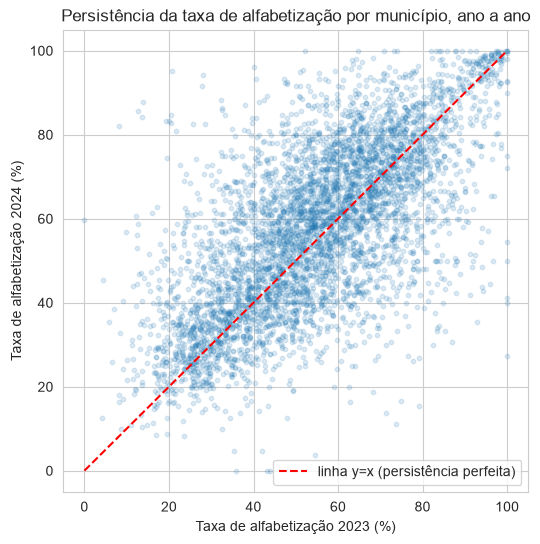

In [2]:
# calculando a taxa de alfabetização por município e ano diretamente da base
# de alunos (não uso a tabela Gold pronta aqui, pra não herdar o filtro
# rede="5" dela sem querer - quero ver o município como um todo)
taxa_municipio_ano = (
    base.groupby(["id_municipio", "ano"])["alfabetizado"]
    .apply(lambda serie: (serie.astype(int) == 1).mean() * 100)
    .reset_index(name="taxa_alfabetizacao")
)

# pivotando para ter 2023 e 2024 lado a lado por município
pivot_municipio = taxa_municipio_ano.pivot(index="id_municipio", columns="ano", values="taxa_alfabetizacao")
pivot_municipio = pivot_municipio.dropna()  # só municípios com dado nos dois anos
pivot_municipio.columns = ["taxa_2023", "taxa_2024"]

print(f"Municípios com dado em 2023 E 2024: {len(pivot_municipio):,}")

correlacao = pivot_municipio["taxa_2023"].corr(pivot_municipio["taxa_2024"], method="spearman")
print(f"Correlação de Spearman entre taxa_2023 e taxa_2024: {correlacao:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(pivot_municipio["taxa_2023"], pivot_municipio["taxa_2024"], alpha=0.15, s=10)
plt.plot([0, 100], [0, 100], color="red", linestyle="--", label="linha y=x (persistência perfeita)")
plt.xlabel("Taxa de alfabetização 2023 (%)")
plt.ylabel("Taxa de alfabetização 2024 (%)")
plt.title("Persistência da taxa de alfabetização por município, ano a ano")
plt.legend()
plt.show()

A correlação de Spearman deu **0.667** entre `taxa_2023` e `taxa_2024` (4.844 municípios com dado nos dois anos) — moderada-alta. Município "bom" em 2023 tende a continuar relativamente bem posicionado em 2024, então existe sim um "efeito município" persistente e não é só ruído de amostra. Isso é evidência de que um score de município baseado em histórico teria fundamento estatístico.

## 3. Pontos que ficariam em aberto se essa arquitetura fosse implementada

Isso não é uma implementação, é o material que reuni pra avaliar se valeria a pena seguir com essa ideia e, se sim, como:

1. **Vale a pena além de `taxa_alfabetizacao_ano_anterior`?** Com só 1 ano de defasagem disponível, um "score" treinado à parte pode não agregar muito sobre simplesmente usar essa coluna (que já está no modelo). A vantagem de um score dedicado só apareceria se ele combinasse histórico + infraestrutura + território de um jeito que um `RandomForestClassifier` normal não capturasse por conta própria — precisaria ser testado, não assumido.
2. **Como evitar leakage na hora de gerar o score para o próprio treino?** Se o score fosse treinado usando dados do mesmo período que ele vai "prever" para o modelo principal, ele "decoraria" os municípios de treino. A forma correta normalmente é gerar o score via predição **fora da amostra** (ex.: `cross_val_predict`), nunca usando o modelo de score treinado com o dado do próprio município que está sendo pontuado.
3. **Isso mudaria a estratégia de validação (GroupKFold)?** Um modelo em duas etapas provavelmente precisaria que a validação por município (Seção 10 do `01_eda.ipynb`) cobrisse as duas etapas juntas, não só a etapa final — outro motivo pra não implementar isso isoladamente sem pensar no pipeline completo.
4. **Valeria o custo de complexidade extra?** Um pipeline de duas etapas é mais difícil de explicar na banca do que um modelo único bem documentado. Se o ganho de performance fosse pequeno, provavelmente não compensaria a complexidade extra para os objetivos deste desafio.

**Conclusão desta exploração:** a checagem da Seção 2 confirmou que existe sinal real — correlação de Spearman de 0.667 entre a taxa de alfabetização de um mesmo município em 2023 e 2024 — então a ideia tinha fundamento estatístico e não era só ruído. Mesmo assim, decidi não seguir com essa arquitetura de duas etapas: o projeto pivotou para modelar diretamente no grão de escola, usando o IDEB (indicador externo do INEP) como alvo, em vez de continuar no grão de aluno com um score de município auxiliar. Uma vez que a unidade de análise virou a escola, o problema que motivou essa exploração (aproveitar o "efeito município" sem perder granularidade de aluno) deixou de se aplicar — no grão de escola, as características de território e histórico entram diretamente como features da própria escola, sem precisar de um modelo auxiliar em duas etapas. Fica documentado aqui como parte do processo de investigação e descarte de alternativas antes de fechar a arquitetura final.